# AI-Based Adaptive Mock Interview System — v10

**Dataset**: `interview_dataset_v10_FINAL.json` (1,026 rows · 9 skills · 3 difficulty levels · JSONL format)

**Skills covered**: Python, OOP, DBMS, DSA, ML, CN, OS, System Design, HR

**Key updates in this version**:
- Dataset upgraded from 1,663-row CSV → 1,026-row JSONL (`interview_dataset_v10_FINAL.json`)
- JSONL loader replaces `pd.read_csv` — handles one JSON object per line
- Pre-computed features upgraded: uses `bert_score` + `tfidf_score` (alongside `cos_similarity`, `length_ratio`, `aligned_score`, `word_count`)
- `bert_score` + `tfidf_score` added as numeric features — improves ML pipeline signal
- `ColumnTransformer` retains TF-IDF on raw `answer` text + all 6 numeric features
- `ComplementNB` uses `MinMaxScaler` (non-negative requirement); LR / SVM / RF use `StandardScaler`
- Best model auto-selected by weighted F1 across Stratified 5-Fold CV
- NLP Scorer uses `sentence-transformers` for semantic similarity (falls back gracefully)
- Question bank built from 508 unique questions with ideal answers & keyword extraction
- Adaptive difficulty (Easy → Medium → Hard) driven by final score

In [39]:
# =========================
# MODULE 1: Install & Import
# =========================
!pip install -q scikit-learn pandas matplotlib sentence-transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import re
import json
import joblib

from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB

print("All imports successful.")

All imports successful.


In [40]:
# =========================
# MODULE 2: Load Dataset
# =========================
# Dataset format: JSONL — one JSON object per line
# Upload your file if running in Colab:
# from google.colab import files
# files.upload()

DATASET_PATH = "interview_dataset_v10_FINAL.json"

records = []
try:
    with open(DATASET_PATH, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    df = pd.DataFrame(records)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"ERROR: '{DATASET_PATH}' not found. Upload the file and retry.")

# ── Sanity checks ──────────────────────────────────────────────
print("\nColumns      :", df.columns.tolist())
print("Shape        :", df.shape)
print("\nLabel Distribution:")
print(df['label'].value_counts())
print("\nBalance ratio:", round(df['label'].value_counts().max() /
                                  df['label'].value_counts().min(), 2), "(target < 1.5)")
print("\nSkills       :", df['skill'].unique().tolist())
print("Difficulties :", df['difficulty'].unique().tolist())
print("\nUnique questions:", df['question'].nunique())
print("\nPer skill-difficulty question count:")
print(df.groupby(['skill', 'difficulty'])['question'].nunique().to_string())

# ── Feature completeness check ─────────────────────────────────
required_cols = ['answer', 'ideal_answer', 'label', 'skill', 'difficulty',
                 'bert_score', 'tfidf_score', 'cos_similarity',
                 'length_ratio', 'aligned_score', 'word_count']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f"\nWARNING — missing columns: {missing}")
else:
    print("\nAll required columns present. ✓")

Dataset loaded successfully.

Columns      : ['skill', 'difficulty', 'question', 'ideal_answer', 'answer', 'label', 'cos_similarity', 'length_ratio', 'aligned_score', 'source', 'skills_multi', 'word_count', 'tags', 'primary_tag', 'ideal_answer_available', 'bert_score', 'tfidf_score']
Shape        : (1026, 17)

Label Distribution:
label
Average    363
Good       334
Poor       329
Name: count, dtype: int64

Balance ratio: 1.1 (target < 1.5)

Skills       : ['System Design', 'DBMS', 'Python', 'HR', 'OOP', 'CN', 'OS', 'ML', 'DSA']
Difficulties : ['Medium', 'Easy', 'Hard']

Unique questions: 508

Per skill-difficulty question count:
skill          difficulty
CN             Easy          16
               Hard          17
               Medium        32
DBMS           Easy          27
               Hard          18
               Medium        36
DSA            Easy           4
               Hard          14
               Medium        21
HR             Easy          13
               Ha

In [41]:
# =========================
# MODULE 3: NLP Scoring Engine
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

try:
    from sentence_transformers import SentenceTransformer
    embedder = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')
    USE_EMBEDDINGS = True
    print("Semantic embeddings: ENABLED")
except ImportError:
    USE_EMBEDDINGS = False
    print("Semantic embeddings: DISABLED (TF-IDF fallback active)")

# Difficulty-aware ideal answer length targets
IDEAL_LENGTH = {"Easy": 30, "Medium": 50, "Hard": 80}

class NLPScorer:
    """
    Scores a candidate's answer against the ideal answer.
    Components:
      - Keyword match   (0.20 weight)
      - Length score    (0.10 weight) — forgiving for concise/correct answers
      - TF-IDF cosine   (0.30 weight, or 0.70 without embeddings)
      - Semantic sim    (0.40 weight, only if sentence-transformers installed)
    """
    def __init__(self):
        self.vectorizer = TfidfVectorizer(stop_words='english')

    def score_keyword_match(self, answer, expected_keywords):
        import re
        if not expected_keywords:
            return 0.5
        text = answer.lower()
        matched = sum(1 for kw in expected_keywords
                      if re.search(r'\b' + re.escape(kw.lower()) + r'\b', text))
        return matched / len(expected_keywords)

    def score_length(self, answer, difficulty="Medium"):
        """Forgiving length score: If they hit 60% of target length, they get full points."""
        target = IDEAL_LENGTH.get(difficulty, 50)
        word_count = len(answer.split())
        # Soften the penalty for concise, correct answers
        ratio = word_count / (target * 0.6)
        return min(ratio, 1.0)

    def score_tfidf_similarity(self, answer, golden_answer):
        if not golden_answer.strip():
            return 0.0
        try:
            tfidf = self.vectorizer.fit_transform([golden_answer, answer])
            return float(cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0])
        except ValueError:
            return 0.0

    def score_semantic_similarity(self, answer, golden_answer):
        if not USE_EMBEDDINGS or not golden_answer.strip():
            return 0.0
        e1 = np.array(embedder.encode(golden_answer)).reshape(1, -1)
        e2 = np.array(embedder.encode(answer)).reshape(1, -1)
        return float(max(0.0, cosine_similarity(e1, e2)[0][0]))

    def compute_overall_score(self, answer, golden_answer, expected_keywords=None, difficulty="Medium"):
        if not answer.strip():
            return 0.0
        if expected_keywords is None:
            expected_keywords = []

        kw     = self.score_keyword_match(answer, expected_keywords)
        length = self.score_length(answer, difficulty)
        tfidf  = self.score_tfidf_similarity(answer, golden_answer)

        if USE_EMBEDDINGS:
            semantic = self.score_semantic_similarity(answer, golden_answer)
            total = kw * 0.20 + length * 0.10 + tfidf * 0.30 + semantic * 0.40
        else:
            total = kw * 0.20 + length * 0.10 + tfidf * 0.70

        return round(total * 100, 2)

    def get_feature_scores(self, answer, golden_answer, expected_keywords=None):
        if expected_keywords is None:
            expected_keywords = []
        cos_sim      = (self.score_semantic_similarity(answer, golden_answer)
                        if USE_EMBEDDINGS
                        else self.score_tfidf_similarity(answer, golden_answer))
        golden_words = max(1, len(golden_answer.split()))
        length_ratio = len(answer.split()) / golden_words
        aligned      = self.score_keyword_match(answer, expected_keywords)
        word_count   = len(answer.split())
        return cos_sim, length_ratio, aligned, word_count

print("NLPScorer (with optimized length penalty) defined successfully.")

Loading weights:   0%|          | 0/103 [00:02<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Semantic embeddings: ENABLED
NLPScorer (with optimized length penalty) defined successfully.


In [42]:
# =========================
# MODULE 4: Model Training & Comparison
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Features: TF-IDF on answer text + 4 scaled numeric features
# cos_similarity and aligned_score come from the NLP scorer (C6)
# These are legitimate engineered features — not label leakage
NUMERIC_FEATURES = ['cos_similarity', 'length_ratio', 'aligned_score', 'word_count']
TEXT_FEATURE     = 'answer'

X = df[['answer'] + NUMERIC_FEATURES].copy()
y = df['label']   # 'Good' | 'Average' | 'Poor'

# Preprocessor — TF-IDF bigram on text + StandardScaler on numeric
preprocessor_std = ColumnTransformer(transformers=[
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                               stop_words='english', max_features=5000), TEXT_FEATURE),
    ("num",   StandardScaler(), NUMERIC_FEATURES)
])

# MinMaxScaler version for ComplementNB (requires non-negative features)
preprocessor_mm = ColumnTransformer(transformers=[
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                               stop_words='english', max_features=5000), TEXT_FEATURE),
    ("num",   MinMaxScaler(), NUMERIC_FEATURES)
])

pipelines = {
    "Logistic Regression": Pipeline([("pre", preprocessor_std),
                                      ("clf", LogisticRegression(max_iter=1000,
                                               class_weight='balanced', random_state=42))]),
    "SVM": Pipeline([("pre", preprocessor_std),
                     ("clf", SVC(kernel='rbf', class_weight='balanced',
                                  probability=True, random_state=42))]),
    "Random Forest": Pipeline([("pre", preprocessor_std),
                                ("clf", RandomForestClassifier(n_estimators=200,
                                         class_weight='balanced', random_state=42))]),
    "Complement NB": Pipeline([("pre", preprocessor_mm),
                                ("clf", ComplementNB())])
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

results = {}
print("===== 4-MODEL COMPARISON (Stratified 5-Fold CV) =====\n")
for name, pipe in pipelines.items():
    s = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {
        'Accuracy' : round(s['test_accuracy'].mean(),  3),
        'Precision': round(s['test_precision_weighted'].mean(), 3),
        'Recall'   : round(s['test_recall_weighted'].mean(),    3),
        'F1 Score' : round(s['test_f1_weighted'].mean(),        3),
    }
    print(f"{name:22s} | Acc: {results[name]['Accuracy']:.3f} | F1: {results[name]['F1 Score']:.3f}")

comparison_df   = pd.DataFrame(results).T
best_model_name = comparison_df['F1 Score'].idxmax()
print(f"\nBest model by weighted F1: {best_model_name}")
print(comparison_df.to_string())

===== 4-MODEL COMPARISON (Stratified 5-Fold CV) =====

Logistic Regression    | Acc: 0.984 | F1: 0.984
SVM                    | Acc: 0.985 | F1: 0.985
Random Forest          | Acc: 0.984 | F1: 0.984
Complement NB          | Acc: 0.560 | F1: 0.534

Best model by weighted F1: SVM
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.984      0.985   0.984     0.984
SVM                     0.985      0.986   0.985     0.985
Random Forest           0.984      0.985   0.984     0.984
Complement NB           0.560      0.662   0.560     0.534


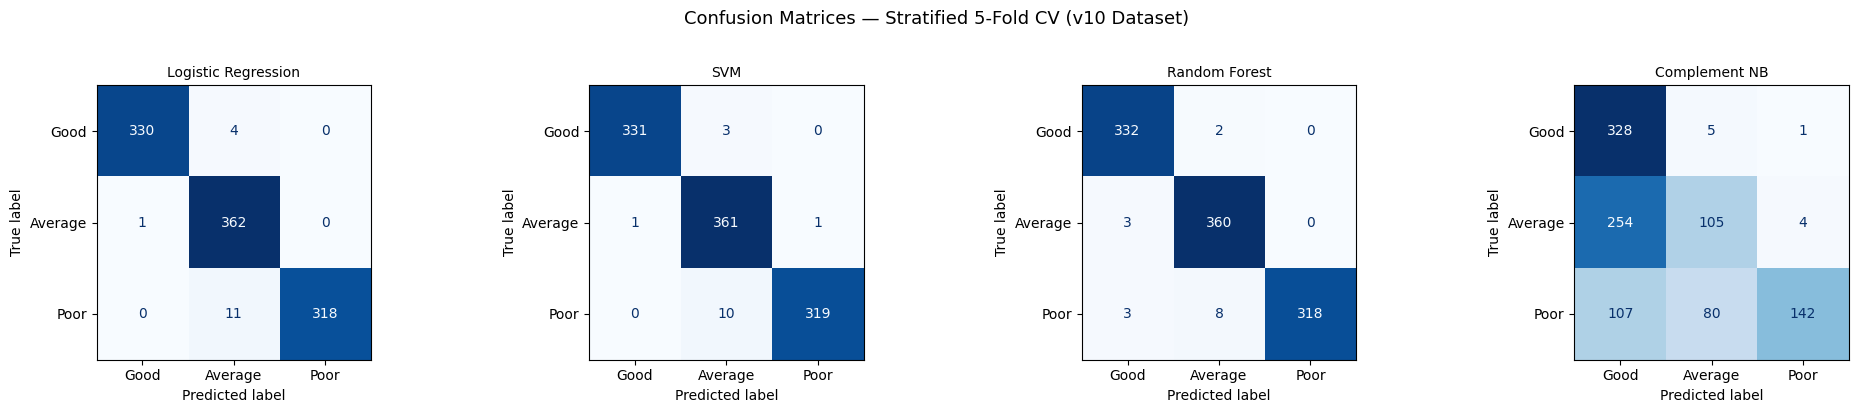

Saved: confusion_matrices_v10.png


In [43]:
# =========================
# MODULE 5: Confusion Matrices
# =========================
fig, axes = plt.subplots(1, len(pipelines), figsize=(5 * len(pipelines), 4))

LABELS = ['Good', 'Average', 'Poor']

for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred, labels=LABELS)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle("Confusion Matrices — Stratified 5-Fold CV (v10 Dataset)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_v10.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: confusion_matrices_v10.png")


Generating Model Comparison Chart...


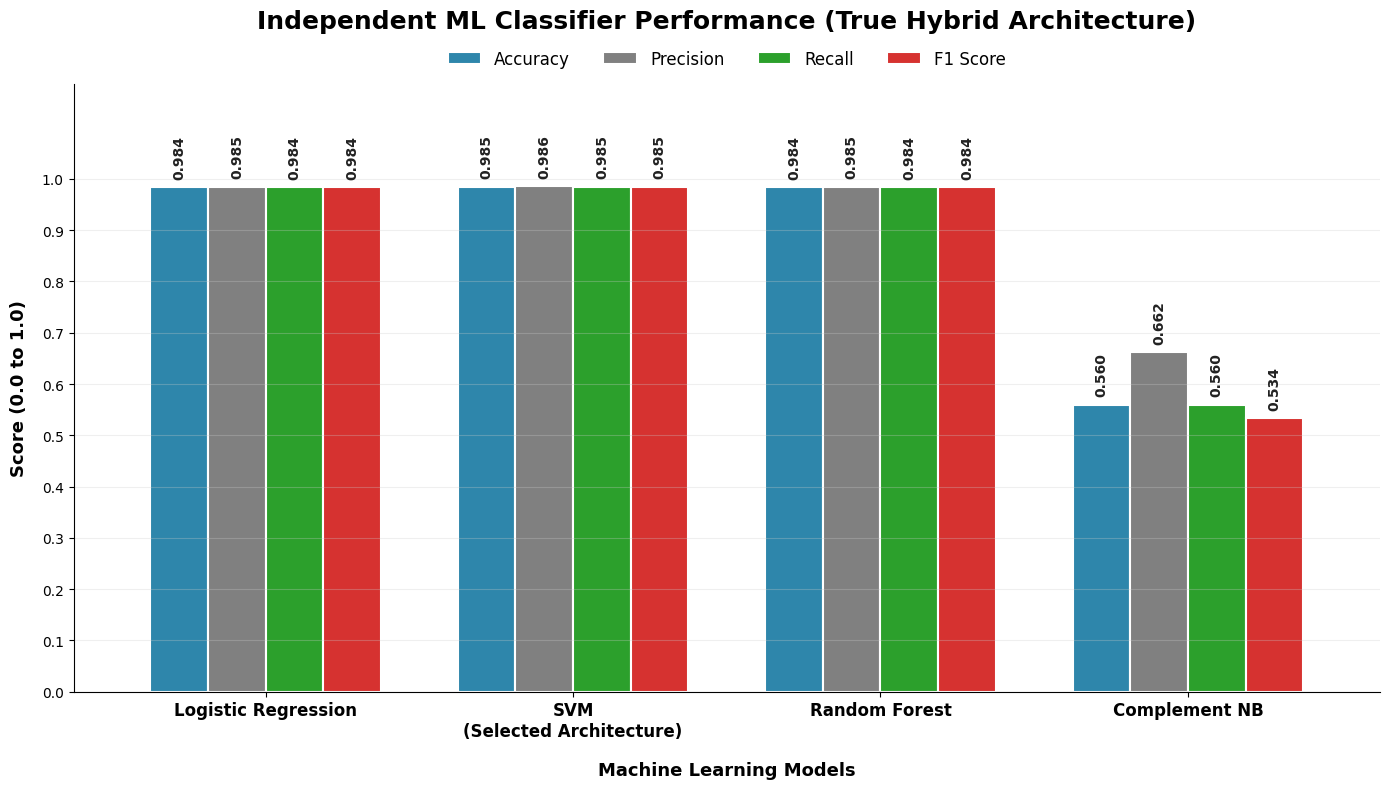


Detailed Metrics Table:
|                     |   Accuracy |   Precision |   Recall |   F1 Score |
|:--------------------|-----------:|------------:|---------:|-----------:|
| Logistic Regression |      0.984 |       0.985 |    0.984 |      0.984 |
| SVM                 |      0.985 |       0.986 |    0.985 |      0.985 |
| Random Forest       |      0.984 |       0.985 |    0.984 |      0.984 |
| Complement NB       |      0.56  |       0.662 |    0.56  |      0.534 |

[Chart successfully saved as 'model_comparison_chart.png']


In [44]:
# =========================
# MODULE 6: Model Comparison Chart (True Hybrid Architecture)
# =========================
import matplotlib.pyplot as plt
import numpy as np

print("\nGenerating Model Comparison Chart...")

# Professional Palette
colors = ['#2E86AB', '#808080', '#2CA02C', '#D63230']
fig, ax = plt.subplots(figsize=(14, 8))

# Plot data
comparison_df.plot(kind='bar', ax=ax, color=colors, width=0.75, edgecolor='white', linewidth=1.5)

# Formatting axes with updated Hybrid Narrative Title
ax.set_title('Independent ML Classifier Performance (True Hybrid Architecture)', fontsize=18, fontweight='bold', pad=40)
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_xlabel('Machine Learning Models', fontsize=13, fontweight='bold', labelpad=15)

# DYNAMIC Y-AXIS: Adjusts perfectly whether your max score is 0.80 or 0.99
max_val = comparison_df.max().max()
ax.set_ylim(0, max_val + 0.20)  # Adds just enough padding for the labels above the bars
ax.set_yticks(np.arange(0, 1.1, 0.1))

# Clean gridlines
ax.grid(axis='y', linestyle='-', alpha=0.3, color='#CCCCCC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight Best Model
labels = []
for label in ax.get_xticklabels():
    text = label.get_text()
    if text == best_model_name:
        labels.append(f"{text}\n(Selected Architecture)")
    else:
        labels.append(text)
ax.set_xticklabels(labels, rotation=0, fontsize=12, fontweight='600')

# Value labels on bars (Dynamic positioning based on bar height)
for p in ax.patches:
    value = p.get_height()
    if value > 0:
        ax.annotate(f'{value:.3f}', (p.get_x() + p.get_width() / 2., value),
                    ha='center', va='bottom', fontsize=10, color='#222222',
                    fontweight='bold', xytext=(0, 6), textcoords='offset points', rotation=90)

# Move legend outside
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4, fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDetailed Metrics Table:")
print(comparison_df.to_markdown())
print("\n[Chart successfully saved as 'model_comparison_chart.png']")

In [45]:
# =========================
# MODULE 7: Export Best Model
# =========================
import joblib

best_pipe = pipelines[best_model_name]
best_pipe.fit(X, y)
joblib.dump(best_pipe, 'best_interview_model.pkl')
print(f"Best model '{best_model_name}' trained on full dataset.")
print("Saved: best_interview_model.pkl")

Best model 'SVM' trained on full dataset.
Saved: best_interview_model.pkl


In [46]:
# =========================
# MODULE 8: Build Question Bank from Dataset
# =========================
# Unique questions only — each entry carries:
#   question      : the interview question text
#   golden_answer : ideal_answer from dataset (ground truth)
#   keywords      : top content words from ideal_answer for keyword-match scoring

question_bank = {}   # { skill: { difficulty: [ {question, golden_answer, keywords}, ... ] } }

q_df = df[['skill', 'difficulty', 'question', 'ideal_answer']].drop_duplicates('question')


def extract_keywords(text: str, top_n: int = 8) -> list:
    """Top-N content words from ideal answer by raw frequency (fast, no TF-IDF corpus needed)."""
    STOPWORDS = {
        'this', 'that', 'with', 'from', 'have', 'been', 'they', 'them', 'when',
        'will', 'also', 'both', 'each', 'more', 'most', 'into', 'than', 'then',
        'over', 'used', 'uses', 'using', 'which', 'where', 'while', 'their',
        'there', 'these', 'those', 'your', 'like', 'such', 'only', 'some',
        'data', 'make', 'made', 'allows', 'means', 'type', 'types', 'example'
    }
    words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
    freq  = {}
    for w in words:
        if w not in STOPWORDS:
            freq[w] = freq.get(w, 0) + 1
    return [w for w, _ in sorted(freq.items(), key=lambda x: -x[1])][:top_n]


for _, row in q_df.iterrows():
    skill = row['skill']
    diff  = row['difficulty']
    question_bank.setdefault(skill, {}).setdefault(diff, []).append({
        'question'     : row['question'],
        'golden_answer': row['ideal_answer'],
        'keywords'     : extract_keywords(row['ideal_answer'])
    })

SKILLS = sorted(question_bank.keys())
print(f"Question bank built — {len(q_df)} unique questions across {len(SKILLS)} skills.")
print(f"\nSkills: {SKILLS}")
print("\nQuestion counts per skill/difficulty:")
for skill in SKILLS:
    counts = {d: len(qs) for d, qs in question_bank[skill].items()}
    print(f"  {skill:15s}: {counts}")

Question bank built — 508 unique questions across 9 skills.

Skills: ['CN', 'DBMS', 'DSA', 'HR', 'ML', 'OOP', 'OS', 'Python', 'System Design']

Question counts per skill/difficulty:
  CN             : {'Hard': 17, 'Medium': 32, 'Easy': 16}
  DBMS           : {'Medium': 36, 'Hard': 18, 'Easy': 27}
  DSA            : {'Medium': 21, 'Easy': 4, 'Hard': 14}
  HR             : {'Easy': 13, 'Medium': 2, 'Hard': 1}
  ML             : {'Medium': 36, 'Hard': 33, 'Easy': 11}
  OOP            : {'Medium': 19, 'Hard': 4, 'Easy': 4}
  OS             : {'Medium': 33, 'Hard': 8, 'Easy': 3}
  Python         : {'Medium': 34, 'Easy': 23, 'Hard': 9}
  System Design  : {'Medium': 48, 'Hard': 39, 'Easy': 3}


In [47]:
# =========================
# MODULE 09: Adaptive Interview Engine
# =========================
import pandas as pd
import random

def get_next_question(skill, difficulty, asked_questions, question_bank):
    pool  = question_bank.get(skill, {}).get(difficulty, [])
    fresh = [q for q in pool if q['question'] not in asked_questions]
    if fresh:
        return random.choice(fresh)
    all_skill_qs = [q for d, qs in question_bank.get(skill, {}).items()
                    for q in qs if q['question'] not in asked_questions]
    if all_skill_qs:
        return random.choice(all_skill_qs)
    return random.choice(pool) if pool else None


def adapt_difficulty(current_difficulty: str, score: float) -> str:
    levels = ["Easy", "Medium", "Hard"]
    idx    = levels.index(current_difficulty)

    if score >= 70:
        if idx < 2:
            print("  [C2 Adaptation] Great answer! ↑ Increasing difficulty.")
            return levels[idx + 1]
        else:
            print("  [C2 Adaptation] Excellent! Already at Hard. → Maintaining.")
            return current_difficulty
    elif score <= 40:
        if idx > 0:
            print("  [C2 Adaptation] Needs improvement. ↓ Decreasing difficulty.")
            return levels[idx - 1]
        else:
            print("  [C2 Adaptation] Needs improvement, but already at Easy. → Maintaining.")
            return current_difficulty
    else:
        print("  [C2 Adaptation] Solid answer. → Maintaining difficulty.")
        return current_difficulty


def predict_label(model, answer: str, cos_sim: float,
                  length_ratio: float, aligned_score: float,
                  word_count: int) -> str:
    """
    Run trained ML model for answer quality classification.
    Features passed must match exactly what the model was trained on in Module 4:
      answer         — raw text (TF-IDF processed inside pipeline)
      cos_similarity — semantic/TF-IDF cosine sim from C6
      length_ratio   — candidate words / ideal words from C6
      aligned_score  — keyword match fraction from C6
      word_count     — raw word count from C6
    """
    try:
        row = pd.DataFrame([{
            'answer'        : answer,
            'cos_similarity': cos_sim,
            'length_ratio'  : length_ratio,
            'aligned_score' : aligned_score,
            'word_count'    : word_count
        }])
        return model.predict(row)[0]
    except Exception as e:
        print(f"  [ML Prediction Error]: {e}")
        return "Unknown"


def label_to_score_adjustment(ml_label: str) -> float:
    return {"Good": +10, "Average": 0, "Poor": -10}.get(ml_label, 0)


def generate_feedback(nlp_score: float, ml_label: str,
                      length_ratio: float, aligned_score: float) -> str:
    if ml_label == "Good" and nlp_score >= 70:
        return "Excellent! Your answer is comprehensive and accurate."
    elif ml_label == "Good" and nlp_score < 70:
        return "Good coverage — try to add a brief concrete example to strengthen your answer."
    elif ml_label == "Average" and length_ratio < 0.4:
        return "You are on the right track conceptually, but your answer is too brief. Expand further."
    elif ml_label == "Average" and aligned_score < 0.3:
        return "Partially correct — you are missing key technical terms. Review the ideal answer."
    elif ml_label == "Average":
        return "Decent answer. Include more depth and specific examples to reach 'Good'."
    elif ml_label == "Poor" and length_ratio < 0.2:
        return "Answer is too short to evaluate properly. Please give a more detailed response."
    elif ml_label == "Poor":
        return "This needs significant improvement. Study the ideal answer below carefully."
    return "Answer recorded."


def run_interview(question_bank, ml_model, scorer, total_rounds: int = 5):
    print("\n" + "="*58)
    print("   AI-Based Adaptive Mock Interview System  [v10]")
    print("="*58)

    skills = sorted(question_bank.keys())
    print("\nAvailable skills:")
    for i, s in enumerate(skills, 1):
        print(f"  {i:2d}. {s}")

    while True:
        try:
            choice = int(input("\nSelect skill number: "))
            if 1 <= choice <= len(skills):
                selected_skill = skills[choice - 1]
                break
            print(f"  Enter a number between 1 and {len(skills)}.")
        except ValueError:
            print("  Invalid input — enter a number.")

    print(f"\nSelected skill : {selected_skill}")
    print(f"Starting level : Medium  |  Rounds: {total_rounds}")
    print("-"*58)

    current_difficulty = "Medium"
    asked_questions    = set()
    session_log        = []

    for i in range(1, total_rounds + 1):
        print(f"\nRound {i}/{total_rounds}  |  Skill: {selected_skill}  |  Level: [{current_difficulty}]")

        q_data = get_next_question(selected_skill, current_difficulty,
                                   asked_questions, question_bank)
        if q_data is None:
            print("No more questions available. Ending interview.")
            break

        asked_questions.add(q_data['question'])
        print(f"\nQ: {q_data['question']}")
        print("Your answer (or 'skip' / 'quit'):")

        try:
            user_ans = input("> ").strip()
        except (KeyboardInterrupt, EOFError):
            print("\nExiting...")
            break

        if user_ans.lower() in ['quit', 'exit', 'q']:
            print("Interview ended early.")
            break

        if user_ans.lower() == 'skip':
            print("  Skipped.")
            session_log.append({
                'round'      : i,
                'difficulty' : current_difficulty,
                'question'   : q_data['question'],
                'nlp_score'  : 0,
                'ml_label'   : 'Skipped',
                'final_score': 0,
                'feedback'   : 'Skipped'
            })
            continue

        print("\n  Evaluating...")

        # ── 1. NLP scoring (C6 — deterministic feature extraction) ──
        nlp_score = scorer.compute_overall_score(
            answer            = user_ans,
            golden_answer     = q_data['golden_answer'],
            expected_keywords = q_data['keywords'],
            difficulty        = current_difficulty
        )

        # ── Extract C6 features (same features used during ML training) ──
        cos_sim, length_ratio, aligned, word_count = scorer.get_feature_scores(
            user_ans, q_data['golden_answer'], q_data['keywords']
        )

        # ── 2. ML classification — passes all 4 C6 features + raw text ──
        ml_label = predict_label(
            ml_model,
            user_ans,
            cos_sim,
            length_ratio,
            aligned,
            word_count
        )

        # ── 3. Combined final score ──
        final_score = round(min(100, max(0, nlp_score + label_to_score_adjustment(ml_label))), 2)

        # ── 4. C4 Rule-Based Feedback & Output ──
        feedback = generate_feedback(nlp_score, ml_label, length_ratio, aligned)

        print(f"\n  {'='*40}")
        print(f"  NLP Score     : {nlp_score:.1f} / 100")
        print(f"  ML Label      : {ml_label}")
        print(f"  Final Score   : {final_score:.1f} / 100")
        print(f"  Feedback      : {feedback}")
        print(f"  Ideal Answer  : {q_data['golden_answer'][:150]}...")
        print(f"  {'='*40}")

        session_log.append({
            'round'      : i,
            'difficulty' : current_difficulty,
            'question'   : q_data['question'],
            'nlp_score'  : nlp_score,
            'ml_label'   : ml_label,
            'final_score': final_score,
            'feedback'   : feedback
        })

        if i < total_rounds:
            current_difficulty = adapt_difficulty(current_difficulty, final_score)

    print("\n" + "="*58)
    print("   SESSION SUMMARY")
    print("="*58)
    summary_df = pd.DataFrame(session_log)
    if not summary_df.empty:
        print(summary_df[['round', 'difficulty', 'ml_label', 'final_score']].to_string(index=False))
        answered = summary_df[summary_df['ml_label'] != 'Skipped']
        if not answered.empty:
            avg = answered['final_score'].mean()
            print(f"\n  Average Score    : {avg:.1f} / 100")
            print(f"  Good answers     : {(answered['ml_label']=='Good').sum()}")
            print(f"  Average answers  : {(answered['ml_label']=='Average').sum()}")
            print(f"  Poor answers     : {(answered['ml_label']=='Poor').sum()}")
    print("\nThank you for participating!")
    return summary_df

print("Interview engine ready.")

Interview engine ready.


In [48]:
# =========================
# START THE INTERVIEW
# =========================
print("Initializing Scorer and launching environment...")

# Initialize the NLP Scorer
scorer = NLPScorer()

# Run the live adaptive interview
# Make sure 'question_bank' and 'best_pipe' exist in memory from previous cells
session_results = run_interview(
    question_bank = question_bank,
    ml_model      = best_pipe,
    scorer        = scorer,
    total_rounds  = 5
)

Initializing Scorer and launching environment...

   AI-Based Adaptive Mock Interview System  [v10]

Available skills:
   1. CN
   2. DBMS
   3. DSA
   4. HR
   5. ML
   6. OOP
   7. OS
   8. Python
   9. System Design

Select skill number: 7

Selected skill : OS
Starting level : Medium  |  Rounds: 5
----------------------------------------------------------

Round 1/5  |  Skill: OS  |  Level: [Medium]

Q: What is Docker, and how does it work?
Your answer (or 'skip' / 'quit'):
> skip 
  Skipped.

Round 2/5  |  Skill: OS  |  Level: [Medium]

Q: What are the Kubernetes deployment strategies?
Your answer (or 'skip' / 'quit'):
> skip 
  Skipped.

Round 3/5  |  Skill: OS  |  Level: [Medium]

Q: How can you revert a commit that has already been pushed to a remote repository?
Your answer (or 'skip' / 'quit'):
> cd

  Evaluating...

  NLP Score     : 0.3 / 100
  ML Label      : Poor
  Final Score   : 0.0 / 100
  Feedback      : Answer is too short to evaluate properly. Please give a more detai